In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
xgb_heart = '/content/drive/MyDrive/results/emissions_full_Heart_XGB.csv'
xgb_diabetes = '/content/drive/MyDrive/results/emissions_full_Diabetes_XGB.csv'
xgb_bank = '/content/drive/MyDrive/results/emissions_full_Bank_XGB.csv'

In [3]:
import pandas as pd

df_1 = pd.read_csv(xgb_heart)
df_2 = pd.read_csv(xgb_diabetes)
df_3 = pd.read_csv(xgb_bank)

In [4]:
 # Definieren der Feature Typen
feature_types = {
    'Diabetes_binary': 'kategorisch',
    'HighBP': 'kategorisch',
    'HighChol': 'kategorisch',
    'CholCheck': 'kategorisch',
    'BMI': 'numerisch',
    'Smoker': 'kategorisch',
    'Stroke': 'kategorisch',
    'HeartDiseaseorAttack': 'kategorisch',
    'PhysActivity': 'kategorisch',
    'Fruits': 'kategorisch',
    'Veggies': 'kategorisch',
    'HvyAlcoholConsump': 'kategorisch',
    'AnyHealthcare': 'kategorisch',
    'NoDocbcCost': 'kategorisch',
    'GenHlth': 'numerisch',
    'MentHlth': 'numerisch',
    'PhysHlth': 'numerisch',
    'DiffWalk': 'kategorisch',
    'Sex': 'kategorisch',
    'Age': 'numerisch',
    'Education': 'numerisch',
    'Income': 'numerisch',
    'age': 'numerisch',
    'job': 'kategorisch',
    'marital': 'kategorisch',
    'education': 'kategorisch',
    'default': 'kategorisch',
    'balance': 'numerisch',
    'housing': 'kategorisch',
    'loan': 'kategorisch',
    'contact': 'kategorisch',
    'day_of_week': 'kategorisch',
    'month': 'kategorisch',
    'duration': 'numerisch',
    'pdays': 'numerisch',
    'previous': 'numerisch',
    'poutcome': 'kategorisch',
    'HeartDisease': 'kategorisch',
    'BMI': 'numerisch',
    'Smoking': 'kategorisch',
    'AlcoholDrinking': 'kategorisch',
    'Stroke': 'kategorisch',
    'PhysicalHealth': 'numerisch',
    'MentalHealth': 'numerisch',
    'DiffWalking': 'kategorisch',
    'Sex': 'kategorisch',
    'AgeCategory': 'kategorisch',
    'Race': 'kategorisch',
    'Diabetic': 'kategorisch',
    'PhysicalActivity': 'kategorisch',
    'GenHealth': 'kategorisch',
    'SleepTime': 'numerisch',
    'Asthma': 'kategorisch',
    'KidneyDisease': 'kategorisch',
    'SkinCancer': 'kategorisch'
}

In [5]:
# Mappen der Features auf die Daten
dataframes = [df_1, df_2, df_3]

for df in dataframes:
  df['num_num_features'] = df['feature_names'].apply(lambda x: sum(1 for feature in x.split(', ') if feature_types.get(feature) == 'numerisch'))
  df['num_cat_features'] = df['feature_names'].apply(lambda x: sum(1 for feature in x.split(', ') if feature_types.get(feature) == 'kategorisch'))

# Ermitteln, wie of ein feature vorgekommen ist

df['feature_names'] = df['feature_names'].str.split(', ')

feature_counts = {}

# Iteriere über jedes DataFrame in der Liste
for df in dataframes:
    df['feature_names'] = df['feature_names'].str.split(', ')
    for index, row in df.iterrows():
        features = row['feature_names']
        if isinstance(features, list):
            for feature in features:
                if feature in feature_counts:
                    feature_counts[feature] += 1
                else:
                    feature_counts[feature] = 1

# Reduction percentage muss jetzt angepasst werden auf die Zahl der Features

Heart Daten satz = 320.000

Diabetes Datensatz = 250.000

Bank Datensatz = 45.211

In [6]:
df_1['number_of_instances'] = 320000 * (1 - df_1['reduction_percentage'] / 100)
df_2['number_of_instances'] =  250000 * (1 - df_2['reduction_percentage'] / 100)
df_3['number_of_instances'] =  45211 * (1 - df_3['reduction_percentage'] / 100)

In [7]:
df = pd.concat([df_1, df_2, df_3])

In [8]:
# Reduzieren der Eingabeparams für das Modell und Analyse
selected_columns = ['energy_consumed', 'num_num_features', 'num_cat_features', 'number_of_instances']

df = df[selected_columns]

In [10]:
df.head()

,energy_consumed,num_num_features,num_cat_features,number_of_instances
0,0.000100,4,13,320000.0
1,0.000023,4,13,256000.0
2,0.000018,4,13,192000.0
3,0.000012,4,13,128000.0
4,0.000031,4,13,64000.0


In [11]:
from sklearn import preprocessing

In [12]:
scaled = preprocessing.scale(df)

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
import numpy as np
wcss =[]

for i in range(1,10):
    kmeans = KMeans(i)
    kmeans.fit(scaled)
    wcss.append(kmeans.inertia_)

wcss

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

[11412.000000000005,
 7550.316954964264,
 5132.019597078275,
 4035.652772951412,
 3462.905980529231,
 2950.701994750664,
 2606.1273864743202,
 2393.2645298546845,
 2206.5272745594093]

Text(0, 0.5, 'WCSS')

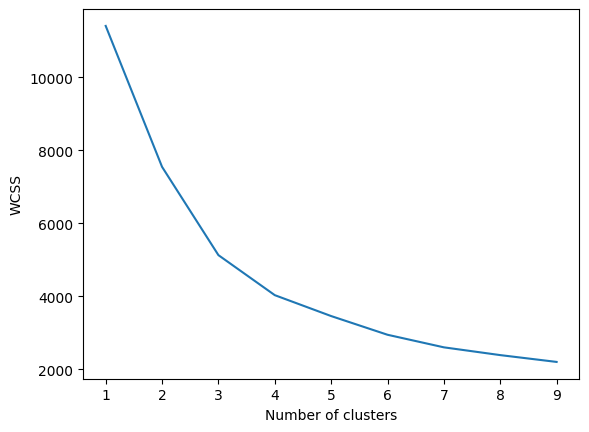

In [14]:
import matplotlib.pyplot as plt
# Plot the number of clusters together with WCSS
plt.plot(range(1,10),wcss)

# Define the axes
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

In [15]:
# Variate K (the number of clusters)
kmeans = KMeans(4)
# Fit the data
kmeans.fit(scaled)

# Create a new data frame with the predicted clusters
clusters_new = df.copy()
clusters_new['cluster_pred'] = kmeans.fit_predict(scaled)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [16]:
clusters_new

,energy_consumed,num_num_features,num_cat_features,number_of_instances,cluster_pred
0,0.000100,4,13,320000.0,3
1,0.000023,4,13,256000.0,3
2,0.000018,4,13,192000.0,3
3,0.000012,4,13,128000.0,3
4,0.000031,4,13,64000.0,3
...,...,...,...,...,...
948,0.000114,0,1,45211.0,2
949,0.000077,0,1,36168.8,1
950,0.000064,0,1,27126.6,1
951,0.000039,0,1,18084.4,1


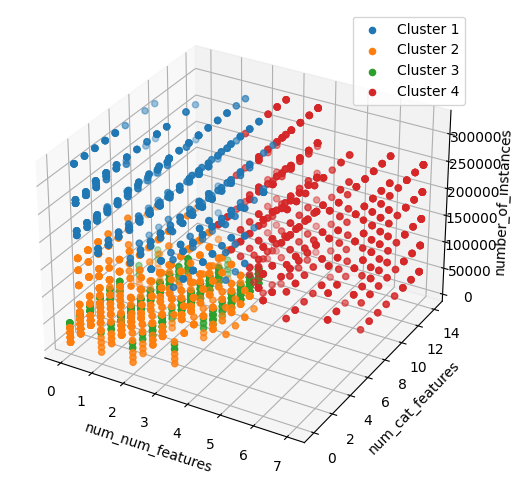

In [17]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for cluster in range(4):
    clustered_data = clusters_new[clusters_new['cluster_pred'] == cluster]
    ax.scatter(clustered_data['num_num_features'], clustered_data['num_cat_features'], clustered_data['number_of_instances'], label=f'Cluster {cluster+1}')

# Achsenbeschriftungen
ax.set_xlabel('num_num_features')
ax.set_ylabel('num_cat_features')
ax.set_zlabel('number_of_instances')

plt.legend()
plt.show()


#vars=['energy_consumed', 'num_num_features', 'num_cat_features', 'number_of_instances'])


## Clustern mit DB Scan

In [105]:
scaled_df = pd.DataFrame(scaled)

In [106]:
scaled_df.head()

,0,1,2,3
0,1.077405,0.802643,1.701052,2.082398
1,-0.431493,0.802643,1.701052,1.411067
2,-0.534128,0.802643,1.701052,0.739736
3,-0.647224,0.802643,1.701052,0.068405
4,-0.285791,0.802643,1.701052,-0.602926


In [117]:
df_db = df
df_db = df_db.drop('cluster_pred', axis=1)

In [24]:
clusters_new.head()

,energy_consumed,num_num_features,num_cat_features,number_of_instances,cluster_pred
0,0.000100,4,13,320000.0,3
1,0.000023,4,13,256000.0,3
2,0.000018,4,13,192000.0,3
3,0.000012,4,13,128000.0,3
4,0.000031,4,13,64000.0,3


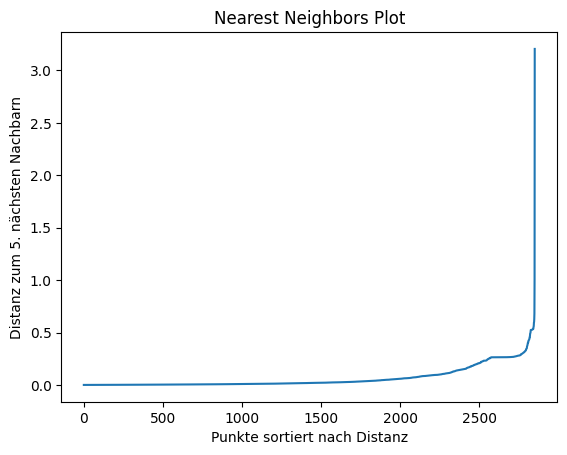

In [122]:
# eps wert finden
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(scaled_df)
distances, indices = neighbors_fit.kneighbors(scaled_df)

# Sortieren der Distanzen
distances = np.sort(distances, axis=0)
distances = distances[:,1]

plt.plot(distances)
plt.title("Nearest Neighbors Plot")
plt.xlabel("Punkte sortiert nach Distanz")
plt.ylabel("Distanz zum " + str(min_samples) + ". nächsten Nachbarn")
plt.show()

In [134]:
from sklearn.cluster import DBSCAN

# DBSCAN-Modell anwenden
epsilon = 0.005
min_samples = 5

dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
dbscan_clusters = dbscan.fit_predict(scaled_df)

# Die Cluster-Labels zum DataFrame hinzufügen
df_db['dbscan_cluster'] = dbscan_clusters

In [135]:
import numpy as np

# Bestimmen der einzigartigen Cluster-Labels
unique_labels = np.unique(df_db['dbscan_cluster'])

# Zählen der Cluster, dabei Ausreißer (Label -1) ausschließen
num_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

print(f"Anzahl der gefundenen Cluster: {num_clusters}")

Anzahl der gefundenen Cluster: 15


In [25]:
df_clusters = clusters_new

In [26]:
df_clusters.head()
df_clusters = df_clusters.drop('energy_consumed', axis=1)

In [27]:
df_clusters.head()

,num_num_features,num_cat_features,number_of_instances,cluster_pred
0,4,13,320000.0,3
1,4,13,256000.0,3
2,4,13,192000.0,3
3,4,13,128000.0,3
4,4,13,64000.0,3


## SVM Model für Clsuter

In [28]:
from sklearn.model_selection import train_test_split

# Angenommen, Ihr DataFrame heißt df
X = df_clusters[['num_num_features', 'num_cat_features', 'number_of_instances']]  # Features
y = df_clusters['cluster_pred']  # Labels

# Aufteilung in Trainings- und Testdatensätze
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [29]:
from sklearn.preprocessing import StandardScaler

# Erstellen eines StandardScaler-Objekts
scaler = StandardScaler()

# Skalieren der Trainingsdaten
X_train_scaled = scaler.fit_transform(X_train)

# Skalieren der Testdaten
X_test_scaled = scaler.transform(X_test)

In [30]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# SVM-Modell erstellen und trainieren
svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)

# Vorhersagen auf Testdaten machen
y_pred = svm_model.predict(X_test_scaled)

# Modellleistung bewerten
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[141   0   0   2]
 [  0 119  29   0]
 [  0  36  87   0]
 [  0   0   1 156]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       143
           1       0.77      0.80      0.79       148
           2       0.74      0.71      0.72       123
           3       0.99      0.99      0.99       157

    accuracy                           0.88       571
   macro avg       0.87      0.87      0.87       571
weighted avg       0.88      0.88      0.88       571



Klasse 0 und 3 zeigen hervorragende Ergebnisse mit fast perfekter Klassifikation.
Klasse 1 und 2 zeigen eine gute Leistung, aber mit einigen Fehlklassifikationen. Besonders bei Klasse 2, wo 36 Instanzen fälschlicherweise als Klasse 1 klassifiziert wurden.


Classification Report
Precision: Die Präzision ist für Klasse 0 und 3 sehr hoch (100% bzw. 99%), was bedeutet, dass fast alle Vorhersagen für diese Klassen korrekt waren. Klasse 1 und 2 haben niedrigere Präzisionswerte (77% bzw. 74%), was auf mehr falsch positive Vorhersagen hinweist.

Recall: Der Recall ist ebenfalls sehr hoch für Klasse 0 und 3. Für Klasse 1 und 2 ist der Recall etwas niedriger, was darauf hindeutet, dass das Modell einige tatsächliche Instanzen dieser Klassen nicht erkannt hat.

F1-Score: Der F1-Score, der ein harmonisches Mittel aus Precision und Recall ist, zeigt ähnliche Muster. Hohe Werte für Klasse 0 und 3 und moderate Werte für Klasse 1 und 2.

Accuracy: Die Gesamtgenauigkeit des Modells liegt bei 88%, was eine sehr gute Leistung darstellt.

#### Kreuzvalidierung

In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2, cv=5)

# Suche nach den besten Hyperparametern
grid.fit(X_train_scaled, y_train)

# Die besten Parameter anzeigen
print(grid.best_params_)

# Modell mit den besten gefundenen Parametern bewerten
grid_predictions = grid.predict(X_test_scaled)
print(classification_report(y_test, grid_predictions))


Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.4s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.5s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.5s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.5s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.5s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.3s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.2s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.2s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.2s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.3s
[CV] END .....................C=0.1, gamma=1, kernel=sigmoid; total time=   0.4s
[CV] END .....................C=0.1, gamma=1, k

## Naive Bayes zu vorhersage der Clsuters

In [32]:
from sklearn.naive_bayes import GaussianNB

# Naive Bayes-Modell erstellen und trainieren
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# Vorhersagen auf Testdaten machen
y_pred_nb = nb_model.predict(X_test_scaled)

# Modellleistung bewerten
print(confusion_matrix(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

[[139   0   0   4]
 [  1 124  23   0]
 [  0  18 105   0]
 [  0   0   2 155]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       143
           1       0.87      0.84      0.86       148
           2       0.81      0.85      0.83       123
           3       0.97      0.99      0.98       157

    accuracy                           0.92       571
   macro avg       0.91      0.91      0.91       571
weighted avg       0.92      0.92      0.92       571



In [33]:
# Verbessern mit GridSearch
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1],
}

naive_bayes = GaussianNB()

grid_search = GridSearchCV(estimator=naive_bayes, param_grid=param_grid, cv=5, verbose=2, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)


print("Beste Hyperparameter:", grid_search.best_params_)
# Das Modell mit den besten Hyperparametern bewerten
y_pred = grid_search.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Beste Hyperparameter: {'var_smoothing': 1e-09}
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       143
           1       0.87      0.84      0.86       148
           2       0.81      0.85      0.83       123
           3       0.97      0.99      0.98       157

    accuracy                           0.92       571
   macro avg       0.91      0.91      0.91       571
weighted avg       0.92      0.92      0.92       571

